# NIST ISF Calibration: Data-Driven Identity/Fuzzy Cutoff

**Goal:** Derive an empirically justified cutoff for the LOW_ID_HIGH_FUZZY flag
by studying how identity-like (precursor-constrained) and fuzzy-like (open) similarity
scores behave for known in-source fragment (ISF) spectra vs normal MS2 spectra.

**Approach:** Random pairing with known ground truth from NIST23 negative-mode spectra.

**Three pair categories:**
1. **TP** — two normal spectra of the same compound (same InChIKey14)
2. **FP** — two normal spectra of different compounds (different InChIKey14)
3. **ISF** — one ISF spectrum + one normal spectrum of the same compound

**Two scores per pair:**
- `identity_score`: entropy similarity WITH precursor mass constraint (±10 ppm)
- `fuzzy_score`: entropy similarity WITHOUT precursor constraint (open match)

**Validation:** Test derived cutoff on Orbitrap HILIC negESI data (Oliver's ISF comments).

**Data:** `data/reference_db/parsed_spectra.csv` — NIST23 library (455K neg-mode spectra,
5,200 ISF-tagged, 182 compounds with both ISF + normal spectra)

In [1]:
import csv
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ms_entropy as me
from scipy import stats
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT = '/Users/ellayoung/Desktop/metabolo_confi_score'
NIST_CSV = f'{ROOT}/data/reference_db/parsed_spectra.csv'
OUT = f'{ROOT}/data/reference_db'

PPM_TOLERANCE = 10  # for precursor-constrained matching

## 1. Parse NIST23 negative-mode spectra

In [2]:
def parse_peaks_string(peaks_str):
    """Parse NIST peaks string like '[[136.04  3.4]\n [214.96  38.4]\n ...]' to numpy array."""
    cleaned = peaks_str.strip('[] \n')
    rows = cleaned.split('\n')
    result = []
    for row in rows:
        row_clean = row.strip(' []')
        if row_clean:
            vals = row_clean.split()
            if len(vals) >= 2:
                result.append([float(vals[0]), float(vals[1])])
    return np.array(result, dtype=np.float32) if result else None


def safe_parse(peaks_str):
    """Safely parse peaks, returning None for invalid."""
    if not isinstance(peaks_str, str) or not peaks_str.strip() or '...' in peaks_str:
        return None
    try:
        return parse_peaks_string(peaks_str)
    except Exception:
        return None


# Stream NIST23, keep only negative mode with valid peaks
print('Parsing NIST23 negative-mode spectra...')
spectra_by_ik14 = defaultdict(lambda: {'normal': [], 'isf': []})
n_parsed = 0
n_skipped = 0

with open(NIST_CSV) as f:
    reader = csv.reader(f)
    header = next(reader)
    idx = {col: i for i, col in enumerate(header)}

    for row in reader:
        # Filter negative mode
        if row[idx['Ion Mode']].strip() != 'N':
            continue

        ik = row[idx['InChIKey']].strip()
        if len(ik) < 14:
            n_skipped += 1
            continue
        ik14 = ik[:14]

        pmz_str = row[idx['Precursor M/Z']].strip()
        if not pmz_str:
            n_skipped += 1
            continue
        try:
            pmz = float(pmz_str)
        except ValueError:
            n_skipped += 1
            continue

        peaks = safe_parse(row[idx['peaks']])
        if peaks is None or len(peaks) < 2:
            n_skipped += 1
            continue

        is_isf = bool(row[idx['in-source_voltage']].strip())
        entry = {
            'name': row[idx['Name']],
            'ik14': ik14,
            'pmz': pmz,
            'peaks': peaks,
            'spectrum_id': row[idx['Spectrum ID']],
            'is_isf': is_isf,
        }

        category = 'isf' if is_isf else 'normal'
        spectra_by_ik14[ik14][category].append(entry)
        n_parsed += 1

        if n_parsed % 100000 == 0:
            print(f'  parsed {n_parsed}...')

# Summary
n_isf_compounds = sum(1 for v in spectra_by_ik14.values() if v['isf'])
n_normal_compounds = sum(1 for v in spectra_by_ik14.values() if v['normal'])
n_both = sum(1 for v in spectra_by_ik14.values() if v['isf'] and v['normal'])
n_isf_spectra = sum(len(v['isf']) for v in spectra_by_ik14.values())
n_normal_spectra = sum(len(v['normal']) for v in spectra_by_ik14.values())

print(f'\nParsed: {n_parsed} spectra ({n_skipped} skipped)')
print(f'Normal: {n_normal_spectra} spectra, {n_normal_compounds} compounds')
print(f'ISF: {n_isf_spectra} spectra, {n_isf_compounds} compounds')
print(f'Compounds with BOTH ISF + normal: {n_both}')

Parsing NIST23 negative-mode spectra...
  parsed 100000...
  parsed 200000...
  parsed 300000...
  parsed 400000...

Parsed: 424469 spectra (31302 skipped)
Normal: 420247 spectra, 18069 compounds
ISF: 4222 spectra, 264 compounds
Compounds with BOTH ISF + normal: 182


## 2. Generate random pairs

Three categories:
- **TP**: same compound, both normal
- **FP**: different compound, both normal
- **ISF**: same compound, one ISF + one normal

In [3]:
def precursor_match(pmz1, pmz2, ppm=PPM_TOLERANCE):
    """Check if two precursor masses match within ±ppm tolerance."""
    return abs(pmz1 - pmz2) / ((pmz1 + pmz2) / 2) * 1e6 <= ppm


def compute_pair_scores(spec1, spec2):
    """Compute identity (precursor-constrained) and fuzzy (open) scores for a pair."""
    # Fuzzy score: open search, no precursor constraint
    fuzzy = me.calculate_entropy_similarity(
        spec1['peaks'], spec2['peaks'],
        ms2_tolerance_in_da=0.05,
        clean_spectra=True,
    )

    # Identity score: only meaningful if precursors match
    if precursor_match(spec1['pmz'], spec2['pmz']):
        identity = fuzzy  # same similarity, but precursor gate passed
    else:
        identity = 0.0  # precursor mismatch → identity search returns nothing

    return identity, fuzzy


N_PAIRS = 5000  # per category

# ── TP pairs: same compound, both normal ──────────────────────────────────
print('Generating TP pairs (same compound, both normal)...')
tp_candidates = [ik14 for ik14, v in spectra_by_ik14.items()
                 if len(v['normal']) >= 2]
print(f'  Compounds with 2+ normal spectra: {len(tp_candidates)}')

tp_pairs = []
attempts = 0
while len(tp_pairs) < N_PAIRS and attempts < N_PAIRS * 10:
    attempts += 1
    ik14 = random.choice(tp_candidates)
    normals = spectra_by_ik14[ik14]['normal']
    s1, s2 = random.sample(normals, 2)
    identity, fuzzy = compute_pair_scores(s1, s2)
    tp_pairs.append({'pair_type': 'TP', 'identity': identity, 'fuzzy': fuzzy,
                     'ik14': ik14, 'pmz1': s1['pmz'], 'pmz2': s2['pmz']})

print(f'  Generated {len(tp_pairs)} TP pairs')

# ── FP pairs: different compound, both normal ─────────────────────────────
print('Generating FP pairs (different compound, both normal)...')
normal_ik14s = [ik14 for ik14, v in spectra_by_ik14.items() if v['normal']]

fp_pairs = []
attempts = 0
while len(fp_pairs) < N_PAIRS and attempts < N_PAIRS * 10:
    attempts += 1
    ik1, ik2 = random.sample(normal_ik14s, 2)
    s1 = random.choice(spectra_by_ik14[ik1]['normal'])
    s2 = random.choice(spectra_by_ik14[ik2]['normal'])
    identity, fuzzy = compute_pair_scores(s1, s2)
    fp_pairs.append({'pair_type': 'FP', 'identity': identity, 'fuzzy': fuzzy,
                     'ik14_1': ik1, 'ik14_2': ik2, 'pmz1': s1['pmz'], 'pmz2': s2['pmz']})

print(f'  Generated {len(fp_pairs)} FP pairs')

# ── ISF pairs: same compound, one ISF + one normal ────────────────────────
print('Generating ISF pairs (same compound, ISF + normal)...')
isf_candidates = [ik14 for ik14, v in spectra_by_ik14.items()
                  if v['isf'] and v['normal']]
print(f'  Compounds with both ISF + normal: {len(isf_candidates)}')

isf_pairs = []
attempts = 0
while len(isf_pairs) < N_PAIRS and attempts < N_PAIRS * 50:
    attempts += 1
    ik14 = random.choice(isf_candidates)
    s_isf = random.choice(spectra_by_ik14[ik14]['isf'])
    s_normal = random.choice(spectra_by_ik14[ik14]['normal'])
    identity, fuzzy = compute_pair_scores(s_isf, s_normal)
    isf_pairs.append({'pair_type': 'ISF', 'identity': identity, 'fuzzy': fuzzy,
                      'ik14': ik14, 'pmz_isf': s_isf['pmz'], 'pmz_normal': s_normal['pmz']})

print(f'  Generated {len(isf_pairs)} ISF pairs')

# Combine
all_pairs = pd.DataFrame(tp_pairs + fp_pairs + isf_pairs)
all_pairs.to_csv(f'{OUT}/nist_isf_pair_scores.csv', index=False)
print(f'\nSaved {len(all_pairs)} pairs → {OUT}/nist_isf_pair_scores.csv')
print(all_pairs['pair_type'].value_counts())

Generating TP pairs (same compound, both normal)...
  Compounds with 2+ normal spectra: 17755
  Generated 5000 TP pairs
Generating FP pairs (different compound, both normal)...
  Generated 5000 FP pairs
Generating ISF pairs (same compound, ISF + normal)...
  Compounds with both ISF + normal: 182
  Generated 5000 ISF pairs

Saved 15000 pairs → /Users/ellayoung/Desktop/metabolo_confi_score/data/reference_db/nist_isf_pair_scores.csv
pair_type
TP     5000
FP     5000
ISF    5000
Name: count, dtype: int64


## 3. Visualize identity vs fuzzy distributions by pair type

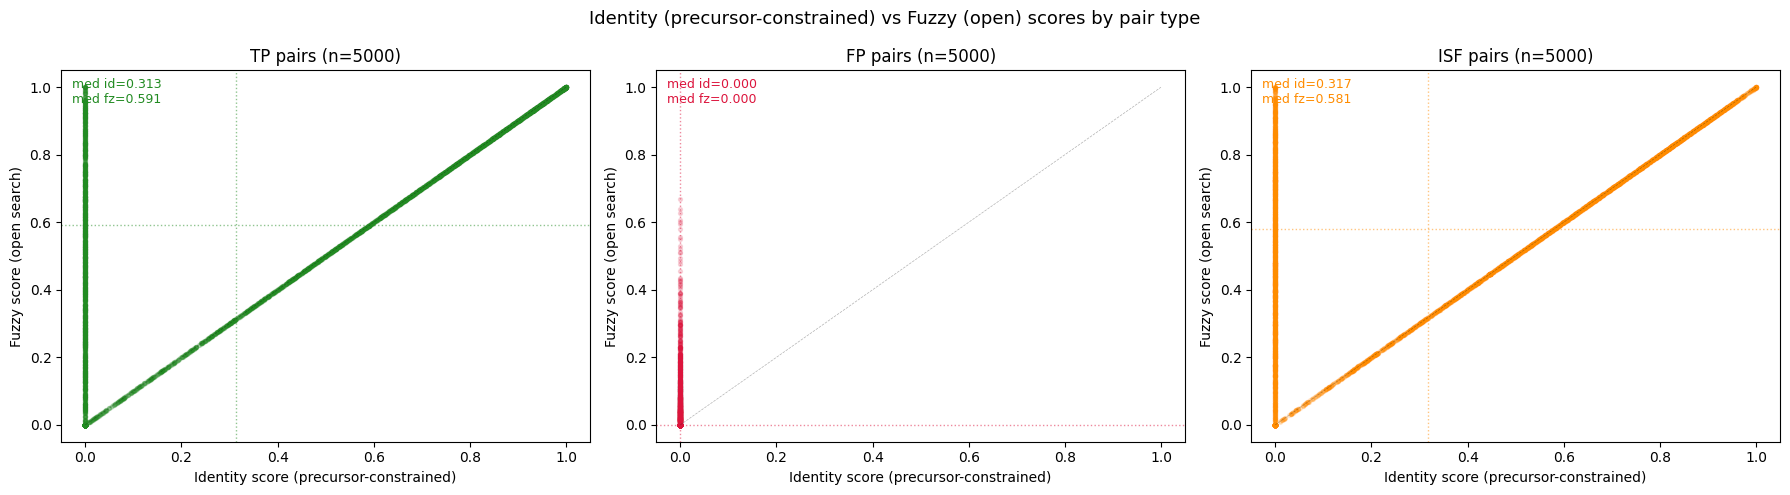

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ptype, color in zip(axes, ['TP', 'FP', 'ISF'], ['forestgreen', 'crimson', 'darkorange']):
    sub = all_pairs[all_pairs['pair_type'] == ptype]
    ax.scatter(sub['identity'], sub['fuzzy'], alpha=0.15, s=8, c=color)
    ax.set_xlabel('Identity score (precursor-constrained)')
    ax.set_ylabel('Fuzzy score (open search)')
    ax.set_title(f'{ptype} pairs (n={len(sub)})')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.5, alpha=0.3)
    # Annotate medians
    ax.axvline(sub['identity'].median(), color=color, ls=':', lw=1, alpha=0.5)
    ax.axhline(sub['fuzzy'].median(), color=color, ls=':', lw=1, alpha=0.5)
    ax.text(0.02, 0.98, f'med id={sub["identity"].median():.3f}\nmed fz={sub["fuzzy"].median():.3f}',
            transform=ax.transAxes, va='top', fontsize=9, color=color)

plt.suptitle('Identity (precursor-constrained) vs Fuzzy (open) scores by pair type', fontsize=13)
plt.tight_layout()
plt.savefig(f'{ROOT}/figures/nist_isf_identity_vs_fuzzy.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 1D distributions and the identity/fuzzy ratio

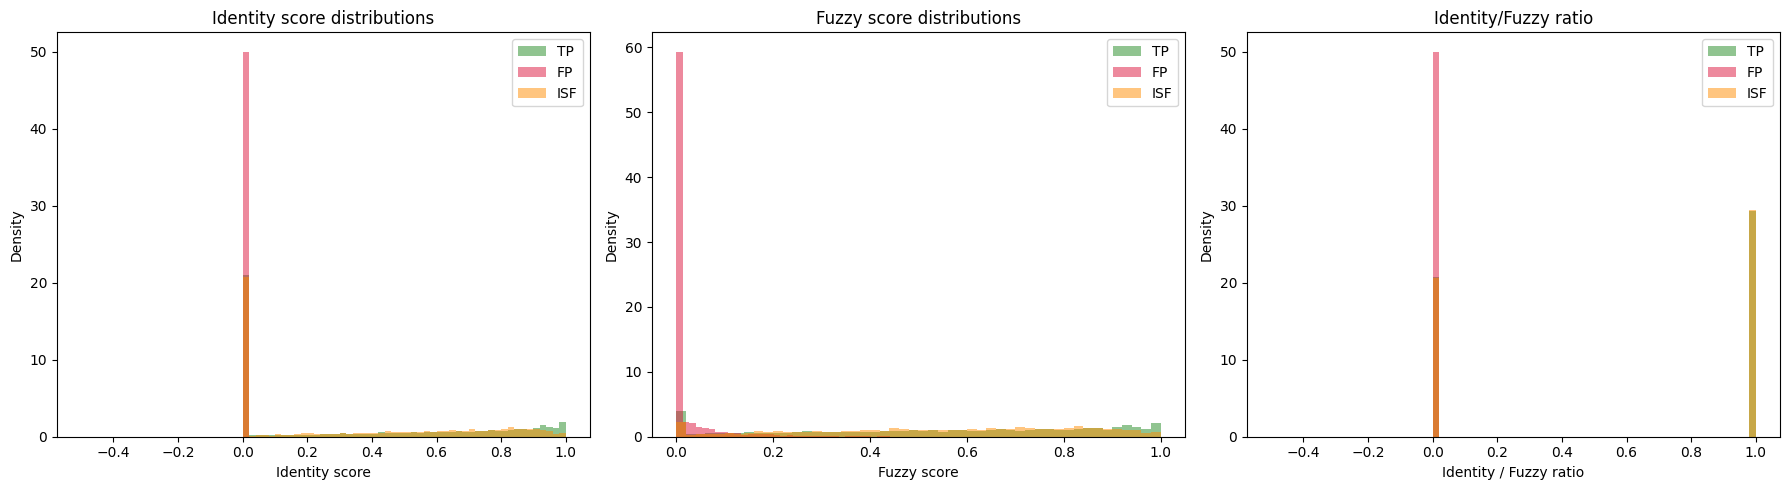

=== Summary statistics ===

TP (n=5000):
  identity: mean=0.383  median=0.313  std=0.383
  fuzzy:    mean=0.553  median=0.591  std=0.311
  ratio:    mean=0.585  median=1.000
  identity=0: 2076 (41.5%)
  fuzzy>0.7:  1965 (39.3%)
  id<0.3 & fz>0.7: 451 (9.0%)

FP (n=5000):
  identity: mean=0.000  median=0.000  std=0.000
  fuzzy:    mean=0.022  median=0.000  std=0.064
  ratio:    mean=0.000  median=0.000
  identity=0: 5000 (100.0%)
  fuzzy>0.7:  0 (0.0%)
  id<0.3 & fz>0.7: 0 (0.0%)

ISF (n=5000):
  identity: mean=0.361  median=0.317  std=0.356
  fuzzy:    mean=0.549  median=0.581  std=0.275
  ratio:    mean=0.588  median=1.000
  identity=0: 2061 (41.2%)
  fuzzy>0.7:  1790 (35.8%)
  id<0.3 & fz>0.7: 508 (10.2%)


In [5]:
# Compute the ratio: identity / (fuzzy + eps)
# ISF spectra should have low ratio (high fuzzy, low identity)
all_pairs['id_fuzzy_ratio'] = all_pairs['identity'] / (all_pairs['fuzzy'] + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Identity score distributions
ax = axes[0]
for ptype, color in [('TP', 'forestgreen'), ('FP', 'crimson'), ('ISF', 'darkorange')]:
    sub = all_pairs[all_pairs['pair_type'] == ptype]
    ax.hist(sub['identity'], bins=50, alpha=0.5, color=color, label=ptype, density=True)
ax.set_xlabel('Identity score')
ax.set_ylabel('Density')
ax.set_title('Identity score distributions')
ax.legend()

# Panel 2: Fuzzy score distributions
ax = axes[1]
for ptype, color in [('TP', 'forestgreen'), ('FP', 'crimson'), ('ISF', 'darkorange')]:
    sub = all_pairs[all_pairs['pair_type'] == ptype]
    ax.hist(sub['fuzzy'], bins=50, alpha=0.5, color=color, label=ptype, density=True)
ax.set_xlabel('Fuzzy score')
ax.set_ylabel('Density')
ax.set_title('Fuzzy score distributions')
ax.legend()

# Panel 3: Ratio distributions
ax = axes[2]
for ptype, color in [('TP', 'forestgreen'), ('FP', 'crimson'), ('ISF', 'darkorange')]:
    sub = all_pairs[all_pairs['pair_type'] == ptype]
    ratio = sub['id_fuzzy_ratio'].clip(0, 2)  # clip for viz
    ax.hist(ratio, bins=50, alpha=0.5, color=color, label=ptype, density=True)
ax.set_xlabel('Identity / Fuzzy ratio')
ax.set_ylabel('Density')
ax.set_title('Identity/Fuzzy ratio')
ax.legend()

plt.tight_layout()
plt.savefig(f'{ROOT}/figures/nist_isf_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('=== Summary statistics ===')
for ptype in ['TP', 'FP', 'ISF']:
    sub = all_pairs[all_pairs['pair_type'] == ptype]
    print(f'\n{ptype} (n={len(sub)}):')
    print(f'  identity: mean={sub["identity"].mean():.3f}  median={sub["identity"].median():.3f}  std={sub["identity"].std():.3f}')
    print(f'  fuzzy:    mean={sub["fuzzy"].mean():.3f}  median={sub["fuzzy"].median():.3f}  std={sub["fuzzy"].std():.3f}')
    print(f'  ratio:    mean={sub["id_fuzzy_ratio"].mean():.3f}  median={sub["id_fuzzy_ratio"].median():.3f}')
    print(f'  identity=0: {(sub["identity"] == 0).sum()} ({(sub["identity"] == 0).mean()*100:.1f}%)')
    print(f'  fuzzy>0.7:  {(sub["fuzzy"] > 0.7).sum()} ({(sub["fuzzy"] > 0.7).mean()*100:.1f}%)')
    print(f'  id<0.3 & fz>0.7: {((sub["identity"] < 0.3) & (sub["fuzzy"] > 0.7)).sum()} '
          f'({((sub["identity"] < 0.3) & (sub["fuzzy"] > 0.7)).mean()*100:.1f}%)')

## 5. ROC analysis: derive optimal cutoff

Binary classification: ISF vs TP. We want a threshold on identity/fuzzy space
that separates ISF pairs from true positive pairs.

Negative ratio (-identity/fuzzy):
  AUC = 0.519
  Youden J = 0.073 at threshold = -1.000
  TPR = 0.883, FPR = 0.811

Fuzzy - Identity gap:
  AUC = 0.516
  Youden J = 0.036 at threshold = 0.172
  TPR = 0.329, FPR = 0.292



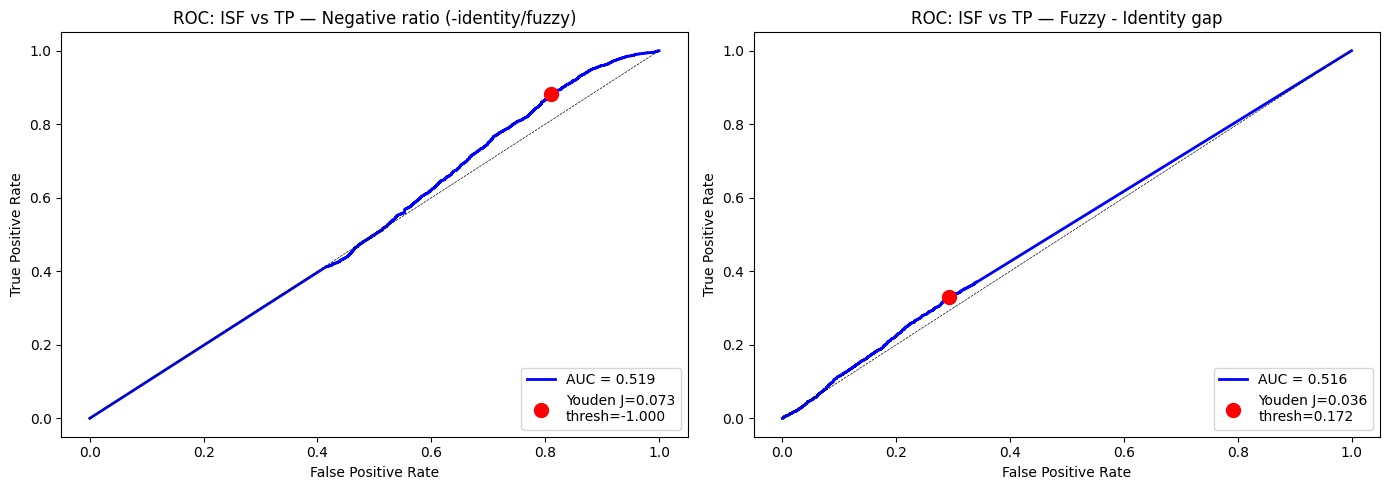

In [6]:
# Binary: ISF=1 vs TP=0
roc_data = all_pairs[all_pairs['pair_type'].isin(['TP', 'ISF'])].copy()
roc_data['is_isf'] = (roc_data['pair_type'] == 'ISF').astype(int)

# Discriminant 1: identity / (fuzzy + eps) — low ratio = ISF
# For ROC, we want high score = ISF, so use negative ratio
roc_data['neg_ratio'] = -roc_data['id_fuzzy_ratio']

# Discriminant 2: fuzzy - identity (high gap = ISF)
roc_data['fuzzy_minus_identity'] = roc_data['fuzzy'] - roc_data['identity']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, score_col, label in [
    (axes[0], 'neg_ratio', 'Negative ratio (-identity/fuzzy)'),
    (axes[1], 'fuzzy_minus_identity', 'Fuzzy - Identity gap'),
]:
    fpr, tpr, thresholds = roc_curve(roc_data['is_isf'], roc_data[score_col])
    roc_auc = auc(fpr, tpr)

    # Youden's J
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thresh = thresholds[best_idx]

    ax.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot(fpr[best_idx], tpr[best_idx], 'ro', markersize=10,
            label=f'Youden J={j_scores[best_idx]:.3f}\nthresh={best_thresh:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC: ISF vs TP — {label}')
    ax.legend(loc='lower right')

    print(f'{label}:')
    print(f'  AUC = {roc_auc:.3f}')
    print(f'  Youden J = {j_scores[best_idx]:.3f} at threshold = {best_thresh:.3f}')
    print(f'  TPR = {tpr[best_idx]:.3f}, FPR = {fpr[best_idx]:.3f}')
    print()

plt.tight_layout()
plt.savefig(f'{ROOT}/figures/nist_isf_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Derive the practical cutoff

In [7]:
# Based on the ROC analysis above, derive practical thresholds.
# We'll test several threshold options and show their precision/recall.

print('=== Threshold sweep: identity < T_id AND fuzzy > T_fz ===')
print(f'{"T_id":<6s} {"T_fz":<6s} {"ISF_recall":<12s} {"TP_FPR":<10s} {"FP_rate":<10s} {"Precision":<10s}')
print('-' * 55)

tp_data = all_pairs[all_pairs['pair_type'] == 'TP']
fp_data = all_pairs[all_pairs['pair_type'] == 'FP']
isf_data = all_pairs[all_pairs['pair_type'] == 'ISF']

best_j = -1
best_params = None

for t_id in [0.1, 0.2, 0.3, 0.4, 0.5]:
    for t_fz in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
        isf_flagged = ((isf_data['identity'] < t_id) & (isf_data['fuzzy'] > t_fz)).mean()
        tp_flagged = ((tp_data['identity'] < t_id) & (tp_data['fuzzy'] > t_fz)).mean()
        fp_flagged = ((fp_data['identity'] < t_id) & (fp_data['fuzzy'] > t_fz)).mean()

        # Precision among flagged
        n_isf_flagged = ((isf_data['identity'] < t_id) & (isf_data['fuzzy'] > t_fz)).sum()
        n_tp_flagged = ((tp_data['identity'] < t_id) & (tp_data['fuzzy'] > t_fz)).sum()
        precision = n_isf_flagged / (n_isf_flagged + n_tp_flagged + 1e-6)

        j = isf_flagged - tp_flagged  # Youden-like
        if j > best_j:
            best_j = j
            best_params = (t_id, t_fz)

        print(f'{t_id:<6.1f} {t_fz:<6.1f} {isf_flagged:<12.1%} {tp_flagged:<10.1%} {fp_flagged:<10.1%} {precision:<10.1%}')

print(f'\nBest (Youden J={best_j:.3f}): identity < {best_params[0]}, fuzzy > {best_params[1]}')

=== Threshold sweep: identity < T_id AND fuzzy > T_fz ===
T_id   T_fz   ISF_recall   TP_FPR     FP_rate    Precision 
-------------------------------------------------------
0.1    0.3    27.4%        24.4%      1.2%       53.0%     
0.1    0.4    23.4%        20.8%      0.5%       52.9%     
0.1    0.5    18.5%        16.7%      0.3%       52.6%     
0.1    0.6    14.3%        12.8%      0.1%       52.8%     
0.1    0.7    10.2%        9.0%       0.0%       53.0%     
0.1    0.8    5.6%         5.7%       0.0%       49.5%     
0.2    0.3    27.4%        24.4%      1.2%       53.0%     
0.2    0.4    23.4%        20.8%      0.5%       52.9%     
0.2    0.5    18.5%        16.7%      0.3%       52.6%     
0.2    0.6    14.3%        12.8%      0.1%       52.8%     
0.2    0.7    10.2%        9.0%       0.0%       53.0%     
0.2    0.8    5.6%         5.7%       0.0%       49.5%     
0.3    0.3    27.4%        24.4%      1.2%       53.0%     
0.3    0.4    23.4%        20.8%      0.5%    

## 7. Validate on Orbitrap data (Oliver's ISF comments)

In [8]:
# Load Orbitrap spreadsheet
raw = pd.read_excel(
    f'{ROOT}/data/masswiki_Orbitrap HILIC negESI_2026-03-19.xlsx',
    sheet_name='masswiki_result_2026-03-19',
    header=4
)

orb = raw.rename(columns={
    'identity_score': 'identity',
    'fuzzy_score': 'fuzzy',
    'Unnamed: 36': 'oliver_comment',
})
orb['identity'] = pd.to_numeric(orb['identity'], errors='coerce')
orb['fuzzy'] = pd.to_numeric(orb['fuzzy'], errors='coerce')

# Flag ISF-related comments
isf_keywords = ['isf', 'in-source', 'in source', 'insource', 'fragment of']
orb['oliver_isf'] = orb['oliver_comment'].fillna('').str.lower().apply(
    lambda c: any(kw in c for kw in isf_keywords)
)

n_oliver_isf = orb['oliver_isf'].sum()
print(f'Oliver ISF comments: {n_oliver_isf}')
print(orb[orb['oliver_isf']][['name', 'identity', 'fuzzy', 'oliver_comment']].to_string())

# Apply the NIST-derived cutoff
# Use the best_params from the sweep above
T_ID, T_FZ = best_params
print(f'\nApplying NIST-derived cutoff: identity < {T_ID}, fuzzy > {T_FZ}')

orb['flag_nist'] = (orb['identity'] < T_ID) & (orb['fuzzy'] > T_FZ)

# Also test the old cutoff
orb['flag_old'] = (orb['identity'] < 0.3) & (orb['fuzzy'] > 0.7)

print(f'\nNIST cutoff flags: {orb["flag_nist"].sum()} ({orb["flag_nist"].mean()*100:.1f}%)')
print(f'Old cutoff flags:  {orb["flag_old"].sum()} ({orb["flag_old"].mean()*100:.1f}%)')

# How many of Oliver's ISF cases does each cutoff catch?
if n_oliver_isf > 0:
    isf_rows = orb[orb['oliver_isf']]
    print(f'\nOliver ISF cases caught by NIST cutoff: {isf_rows["flag_nist"].sum()}/{n_oliver_isf}')
    print(f'Oliver ISF cases caught by old cutoff:  {isf_rows["flag_old"].sum()}/{n_oliver_isf}')
    print(f'\nOliver ISF cases detail:')
    for _, row in isf_rows.iterrows():
        print(f'  {row["name"]:<40s} id={row["identity"]:.3f} fz={row["fuzzy"]:.3f} '
              f'nist={row["flag_nist"]}  old={row["flag_old"]}  // {row["oliver_comment"]}')

Oliver ISF comments: 7
                                      name  identity     fuzzy                                                                                   oliver_comment
478                       N-acetylcysteine  0.643868  0.651671  alternative Sulforaphane N-acetyl-L-cysteine as in-source fragment of sulforaphane, deltaRT 38s
479                       N-acetylcysteine  0.709474  0.713222  alternative Sulforaphane N-acetyl-L-cysteine as in-source fragment of sulforaphane, deltaRT 34s
481                      N-acetylcarnosine  0.962931  0.962931    perfect peak, perfect MSMS, high entropy, no alternative, not an ISF…just delta RTpred is off
500                          taurine_minor  0.999949  0.999949                                                                                   ISF to taurine
501                                taurine  0.937484  0.937484                                                                                   ISF to taurine
1553            N

## 8. Summary and recommended cutoff

In [9]:
print('=== NIST ISF Calibration Summary ===')
print(f'\nNIST23 neg-mode data:')
print(f'  Normal spectra: {n_normal_spectra}')
print(f'  ISF spectra: {n_isf_spectra}')
print(f'  Compounds with both: {n_both}')
print(f'  Pairs generated: {len(all_pairs)} (TP={len(tp_pairs)}, FP={len(fp_pairs)}, ISF={len(isf_pairs)})')
print(f'\nRecommended cutoff: identity < {best_params[0]}, fuzzy > {best_params[1]}')
print(f'  (Youden J = {best_j:.3f})')
print(f'\nTo use in flag_suspicious.ipynb:')
print(f"  df['FLAG_LOW_ID_HIGH_FUZZY'] = (df['identity'] < {best_params[0]}) & (df['fuzzy'] > {best_params[1]})")

=== NIST ISF Calibration Summary ===

NIST23 neg-mode data:
  Normal spectra: 420247
  ISF spectra: 4222
  Compounds with both: 182
  Pairs generated: 15000 (TP=5000, FP=5000, ISF=5000)

Recommended cutoff: identity < 0.5, fuzzy > 0.3
  (Youden J = 0.049)

To use in flag_suspicious.ipynb:
  df['FLAG_LOW_ID_HIGH_FUZZY'] = (df['identity'] < 0.5) & (df['fuzzy'] > 0.3)
